In [6]:
%load_ext autoreload
%autoreload 2
import torch
from torch import nn
from Systems import VdP
import numpy as np
from NN import Main_Network, NN
import matplotlib.pyplot as plt
from Dataset import DataSet
from Normalizer import Normalizer
from Trainer import Trainer
import scipy.io as spio
from Observer import System_z, Observer
import torch.nn.functional as F

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


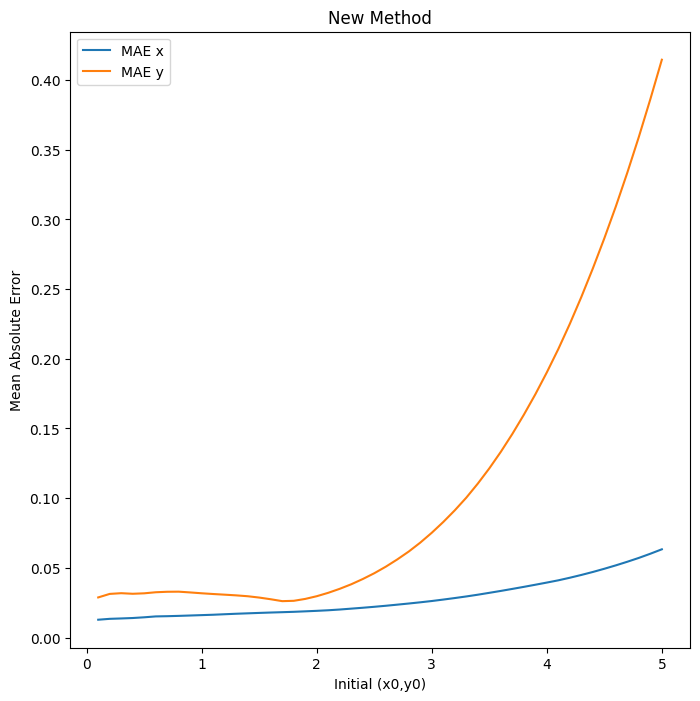

In [10]:
#------------- Van der Pol ------------- 
limits_normal = np.array([[-1,1], [-1,1]])    # Sample space
a = 0   # start
b = 50  # end
N = 1000          # Number of intervals for RK4
num_ic = 50        # Number of initial conditions to be sampled

M = np.diag([-1,-2,-3,-4,-5])    # Choose M matrix
K = np.array([[1,1,1,1,1]]).T    # Choose K matrix

vdp = VdP(zdim = 5, my = 1)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

N = 1000
a = 0
b = 50

model_data = torch.load('models/vdp_T_inverse_lr0.001_batch32_epoch15', map_location=torch.device('cpu'))
num_hidden = model_data['config']['num_hidden']
hidden_size = model_data['config']['hidden_size']
x_size = model_data['config']['x_size']
z_size = model_data['config']['z_size']
activation = model_data['config']['activation']
normalizer = model_data['config']['normalizer']
T_inv_net = NN(num_hidden, hidden_size, z_size, x_size, activation, normalizer=normalizer).to(device)
T_inv_net.load_state_dict(model_data['model'])
T_inv_net.eval()

observer2 = Observer(vdp, M, K, T_inv_net, a, b, N, init_z_zero=True)

initial_conds = np.arange(0.1, 5.1, 0.1)
MAE_x_list_new = []
MAE_y_list_new = []

for ic in initial_conds:
    ic = np.array([[ic, ic]])
    x, x_hat, t, error = observer2.simulate(ic, add_noise = False)
    MAE_x = np.mean(error[0][:,0])
    MAE_y = np.mean(error[0][:,1])
    MAE_x_list_new.append(MAE_x)
    MAE_y_list_new.append(MAE_y)

fig = plt.figure(figsize = (8,8), facecolor='w')
plt.plot(initial_conds, MAE_x_list_new, label = 'MAE x')
plt.plot(initial_conds, MAE_y_list_new, label = 'MAE y')
plt.legend()
plt.title('New Method')
plt.xlabel('Initial (x0,y0)')
plt.ylabel('Mean Absolute Error')
plt.show()

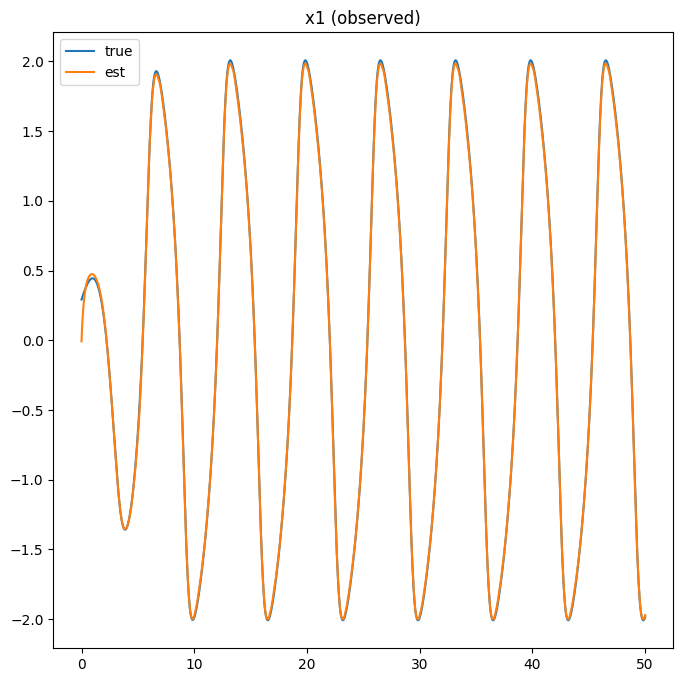

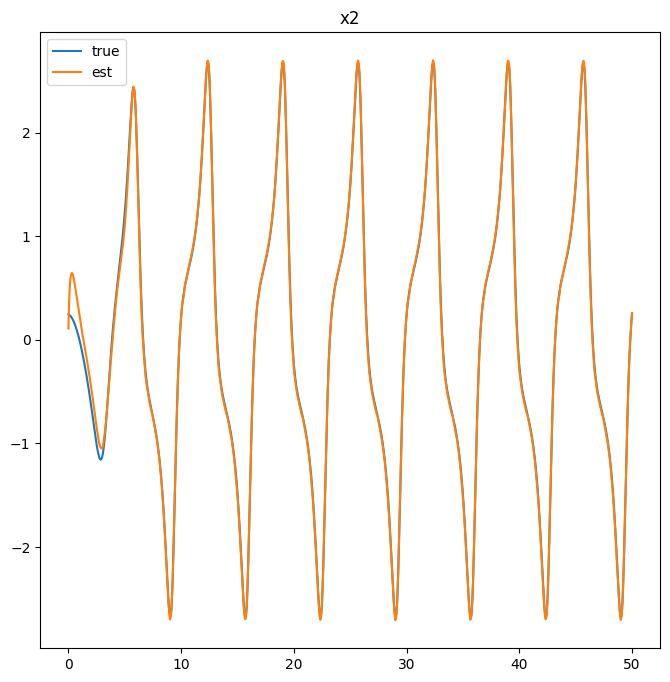

In [4]:
ic = np.array([[0.5, 0.5]])
ic = np.random.uniform(-1,1,[1,2])

x, x_hat, t, error = observer2.simulate(ic, add_noise = False)
fig = plt.figure(figsize = (8,8), facecolor='w')
plt.plot(t, x[:,0], label = 'true')
plt.plot(t, x_hat[:,0], label = 'est')
plt.title('x1 (observed)')
plt.legend()
plt.show()

fig = plt.figure(figsize = (8,8), facecolor='w')
plt.plot(t, x[:,1], label = 'true')
plt.plot(t, x_hat[:,1], label = 'est')
plt.title('x2')
plt.legend()
plt.show()

In [5]:
def eval_errors(xs, xs_predict):
    errs = np.sqrt(((xs - xs_predict) ** 2).mean(-1).mean(0))
    tot = errs.mean()
    return tot

num_ic = 1000
init_conds = np.random.uniform(-1,1,[num_ic,1,2])

x_true = np.zeros([num_ic, N+1, vdp.x_size])
x_pred = np.zeros([num_ic, N+1, vdp.x_size])

for idx, ic in enumerate(init_conds):
    x, x_hat, t, error = observer2.simulate(ic, add_noise = False)
    x_true[idx, :,:] = x
    x_pred[idx, :,:] = x_hat

x_true = x_true[:,50:,:]
x_pred = x_pred[:,50:,:]


print(eval_errors(x_true, x_pred))

0.019672662060421574


In [5]:
print(T_inv_net)

NN(
  (layers): ModuleList(
    (0): Linear(in_features=5, out_features=350, bias=True)
    (1): Linear(in_features=350, out_features=350, bias=True)
    (2): Linear(in_features=350, out_features=2, bias=True)
  )
  (dropout): Dropout(p=0.0, inplace=False)
)
